## Poleward Heat Transport

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%%capture 
# comment above line to see details about the run(s) displayed
from misc import *
import intake
import xarray as xr
import cftime
from datetime import timedelta
import numpy as np
%matplotlib inline

In [3]:
heat_transport = []
heat_transport_ts = []
for path, case in zip(ocn_path, casename):
  ds = xr.open_dataset(path+case+'_heat_transport.nc')
  heat_transport.append(ds)
  ds_ts = xr.open_dataset(path+case+'_heat_transport_ts.nc')
  heat_transport_ts.append(ds_ts)

In [4]:
# load pht-johns-2023 from oce-catalog
obs = 'pht-johns-2023'
catalog = intake.open_catalog(diag_config_yml['oce_cat'])
print('\n Reading data from: ', obs)
ds_obs = catalog[obs].to_dask()


 Reading data from:  pht-johns-2023


In [5]:
# Get the number of days in each month as a DataArray
weights = xr.DataArray(ds_obs.time.dt.days_in_month, coords=[ds_obs.time], dims=["time"])

# Broadcast and compute weighted monthly mean
def weighted_monthly_mean(da):
    w = weights.broadcast_like(da)
    return (da * w).resample(time="MS").sum() / w.resample(time="MS").sum()

pht_johns_2023 = weighted_monthly_mean(ds_obs['Q_sum'])

In [6]:
def shift_to_year1(ds_or_da):
    """
    Shift a dataset or DataArray time coordinate to year 1 using cftime.
    Works for numpy.datetime64 dates by converting them to cftime.
    """
    shifted = ds_or_da.copy()
    
    # Convert numpy.datetime64 to cftime.DatetimeNoLeap if needed
    old_time = shifted.time.values
    if np.issubdtype(old_time.dtype, np.datetime64):
        cftime_time = [cftime.DatetimeNoLeap(t.astype('datetime64[Y]').item().year,
                                             t.astype('datetime64[M]').item().month,
                                             t.astype('datetime64[D]').item().day)
                       for t in old_time]
    else:
        cftime_time = list(old_time)
    
    # Compute deltas in days relative to first timestep
    delta_days = [(t - cftime_time[0]).days for t in cftime_time]
    
    # New origin
    new_origin = cftime.DatetimeNoLeap(1, 1, 1)
    new_time = [new_origin + timedelta(days=d) for d in delta_days]
    
    # Assign new time coordinate
    shifted['time'] = new_time
    return shifted


## Global Poleward Heat Transport

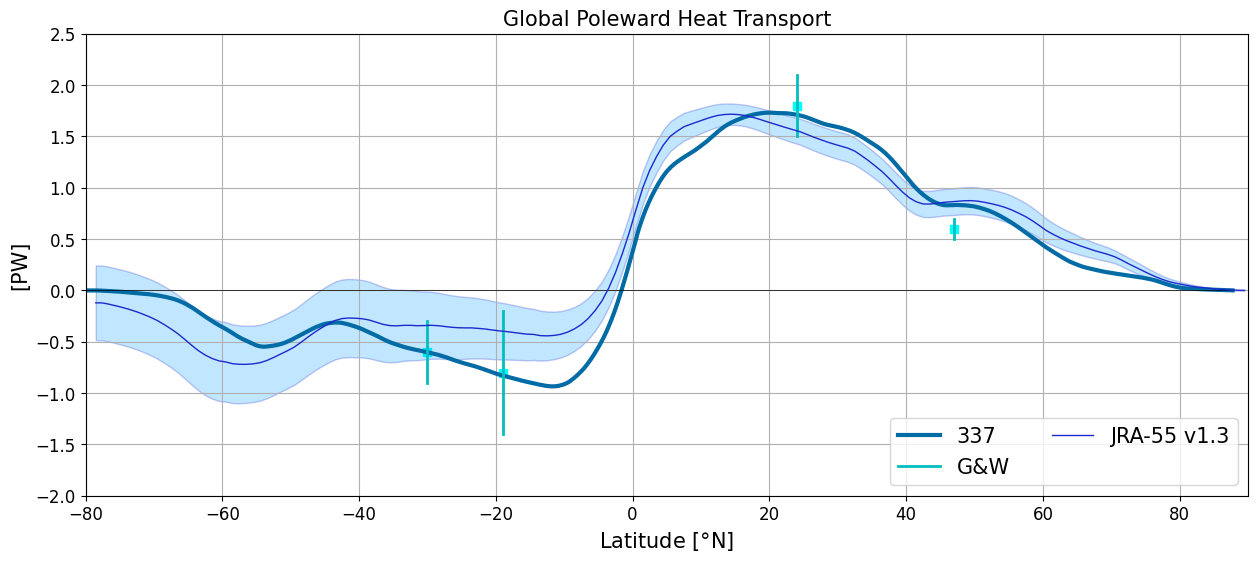

In [7]:
plt.figure(figsize=(15,6))

for i in range(len(casename)):
    plot_heat_trans(heat_transport[i], label=label[i])
  
y = heat_transport[0].yq
plt.xlim(-80,90); plt.ylim(-2.5,3.0); plt.grid(True); 
plt.plot(y, y*0., 'k', linewidth=0.5)
#plt.plot(yobs,NCEP['Global'],'k--',linewidth=0.5,label='NCEP'); 
#plt.plot(yobs,ECMWF['Global'],'k.',linewidth=0.5,label='ECMWF')
plotGandW(GandW['Global']['lat'],GandW['Global']['trans'],GandW['Global']['err'])
jra = xr.open_dataset('/glade/work/gmarques/cesm/datasets/Heat_transport/jra55fcst_v1_3_annual_1x1/nht_jra55do_v1_3.nc')
jra_mean_global = jra.nht[:,0,:].mean('time').values
jra_std_global = jra.nht[:,0,:].std('time').values
plt.plot(jra.lat, jra_mean_global,'k', label='JRA-55 v1.3', color='#1B2ACC', lw=1)
plt.fill_between(jra.lat, jra_mean_global-jra_std_global, jra_mean_global+jra_std_global,
    alpha=0.25, edgecolor='#1B2ACC', facecolor='#089FFF')

plt.title('Global Poleward Heat Transport',fontsize=15)
plt.xlabel(r'Latitude [$\degree$N]',fontsize=15)
plt.ylabel('[PW]',fontsize=15)
plt.legend(loc=4,fontsize=15, ncol=2)
plt.ylim(-2.,2.5);

### Time series @ Equator

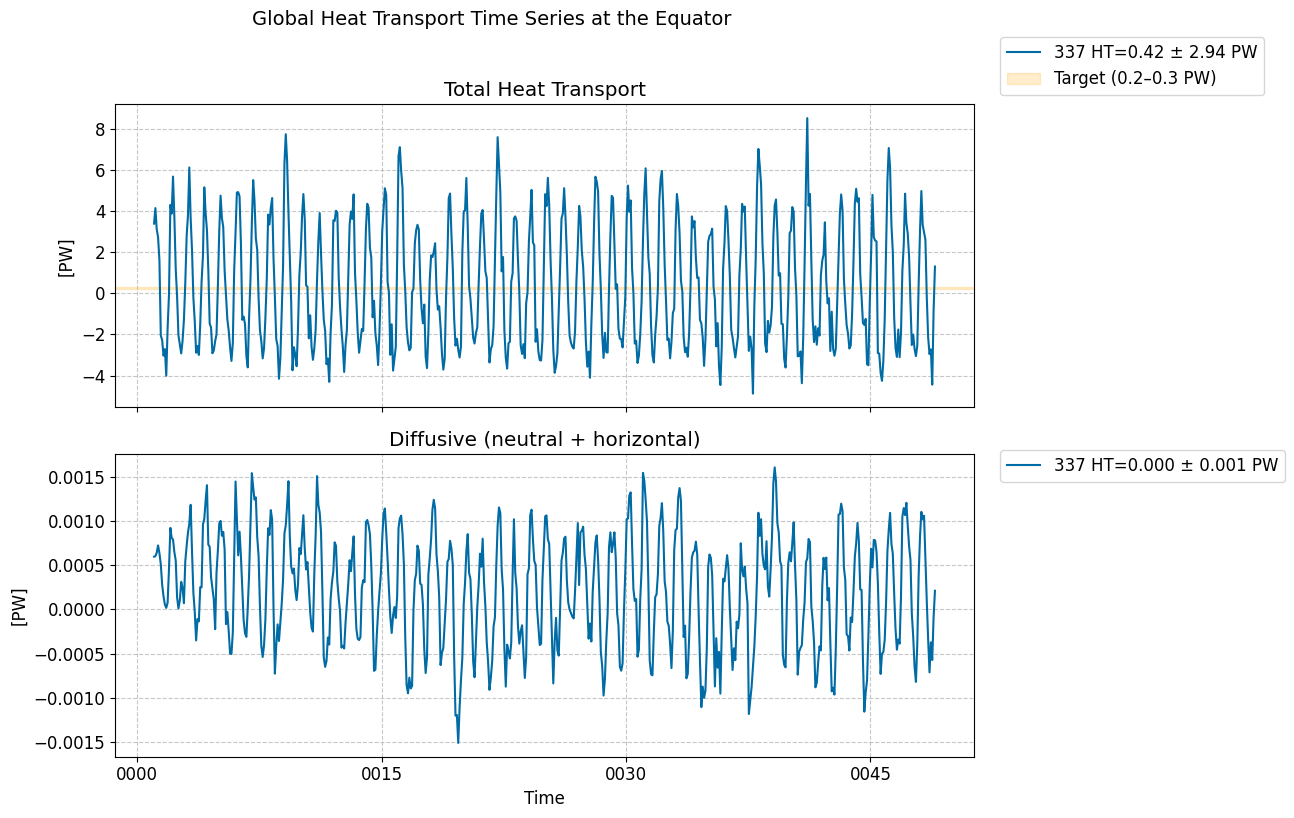

In [8]:
fig, [ax1,ax2] = plt.subplots(nrows=2,figsize=(10,8),sharex=True)

for i in range(len(casename)):
    total = (heat_transport_ts[i].T_ady_2d_global_eq + heat_transport_ts[i].T_diffy_2d_global_eq + \
            heat_transport_ts[i].T_hbd_diffy_2d_global_eq)*1.0e-15 # in PW
    total.plot(ax=ax1, label=str(label[i])+ f" HT={total.mean().values:.2f} ± {total.std().values:.2f} PW") # in PW
    
    diff = (heat_transport_ts[i].T_diffy_2d_global_eq + heat_transport_ts[i].T_hbd_diffy_2d_global_eq)*1.0e-15 # in PW
    diff.plot(ax=ax2, label=str(label[i])+ f" HT={diff.mean().values:.3f} ± {diff.std().values:.3f} PW") # in PW

# Add shaded band to highlight target range
ax1.axhspan(0.2, 0.3, color="orange", alpha=0.2, label="Target (0.2–0.3 PW)")

# Collect handles and labels from one axis (assuming they are the same)
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Put one legend on the right
fig.legend(handles1, labels1, loc="center left", bbox_to_anchor=(1, 0.95))
fig.legend(handles2, labels2, loc="center left", bbox_to_anchor=(1, 0.45))

#  Top title
fig.suptitle("Global Heat Transport Time Series at the Equator", fontsize=14, y=1.02) 
# Titles for each subplot
ax1.set_title("Total Heat Transport")
ax2.set_title("Diffusive (neutral + horizontal)")

# Axis labels
ax1.set_xlabel("")
ax2.set_xlabel("Time")               
ax1.set_ylabel("[PW]")
ax2.set_ylabel("[PW]")

# grid
ax1.grid(True, which="both", linestyle="--", alpha=0.7)
ax2.grid(True, which="both", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

## Atlantic Poleward Heat Transport

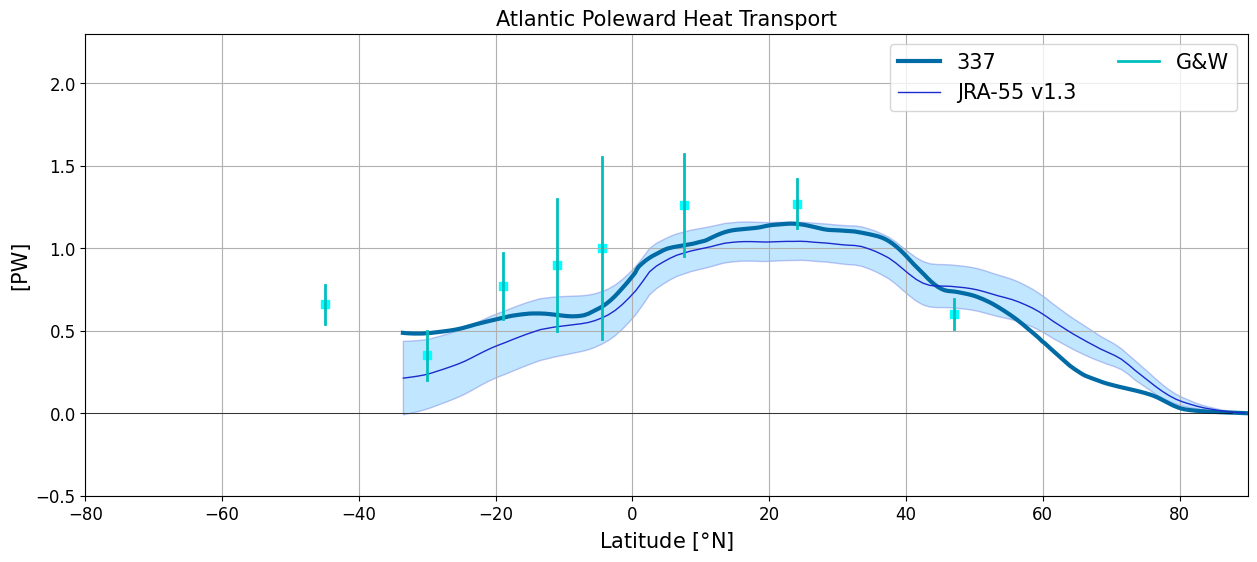

In [9]:
plt.figure(figsize=(15,6))

for i in range(len(casename)):
  basin_code = genBasinMasks(grd[i].geolon, grd[i].geolat, depth[i])
  m = 0*basin_code; m[(basin_code==2) | (basin_code==4) | (basin_code==6) | (basin_code==7) | (basin_code==8)] = 1

  HTplot = heatTrans(heat_transport[i].T_ady_2d, 
           heat_transport[i].T_diffy_2d,
           heat_transport[i].T_hbd_diffy_2d,
           vmask=m*np.roll(m,-1,axis=-2))

  yy = grd[i].geolat_c[:,:].max(axis=-1)
  HTplot[yy<-34] = np.nan
  plt.plot(yy,HTplot, linewidth=3,label=label[i])
  
jra_mean_atl = jra.nht[:,1,:].mean('time').values
jra_std_atl = jra.nht[:,1,:].std('time').values
plt.plot(jra.lat, jra_mean_atl,'k', label='JRA-55 v1.3', color='#1B2ACC', lw=1)
plt.fill_between(jra.lat, jra_mean_atl-jra_std_atl, jra_mean_atl+jra_std_atl,
alpha=0.25, edgecolor='#1B2ACC', facecolor='#089FFF')
#plt.plot(yobs,NCEP['Atlantic'],'k--',linewidth=0.5,label='NCEP')
#plt.plot(yobs,ECMWF['Atlantic'],'k.',linewidth=0.5,label='ECMWF')
plotGandW(GandW['Atlantic']['lat'],GandW['Atlantic']['trans'],GandW['Atlantic']['err'])
plt.xlabel(r'Latitude [$\degree$N]',fontsize=15)
plt.title('Atlantic Poleward Heat Transport',fontsize=15)
plt.legend(ncol=2,fontsize=15)
plt.ylabel('[PW]',fontsize=15)
plt.xlim(-80,90); plt.ylim(-0.5,2.3); plt.grid(True)
plt.plot(y, y*0., 'k', linewidth=0.5);

### Time series @ Equator

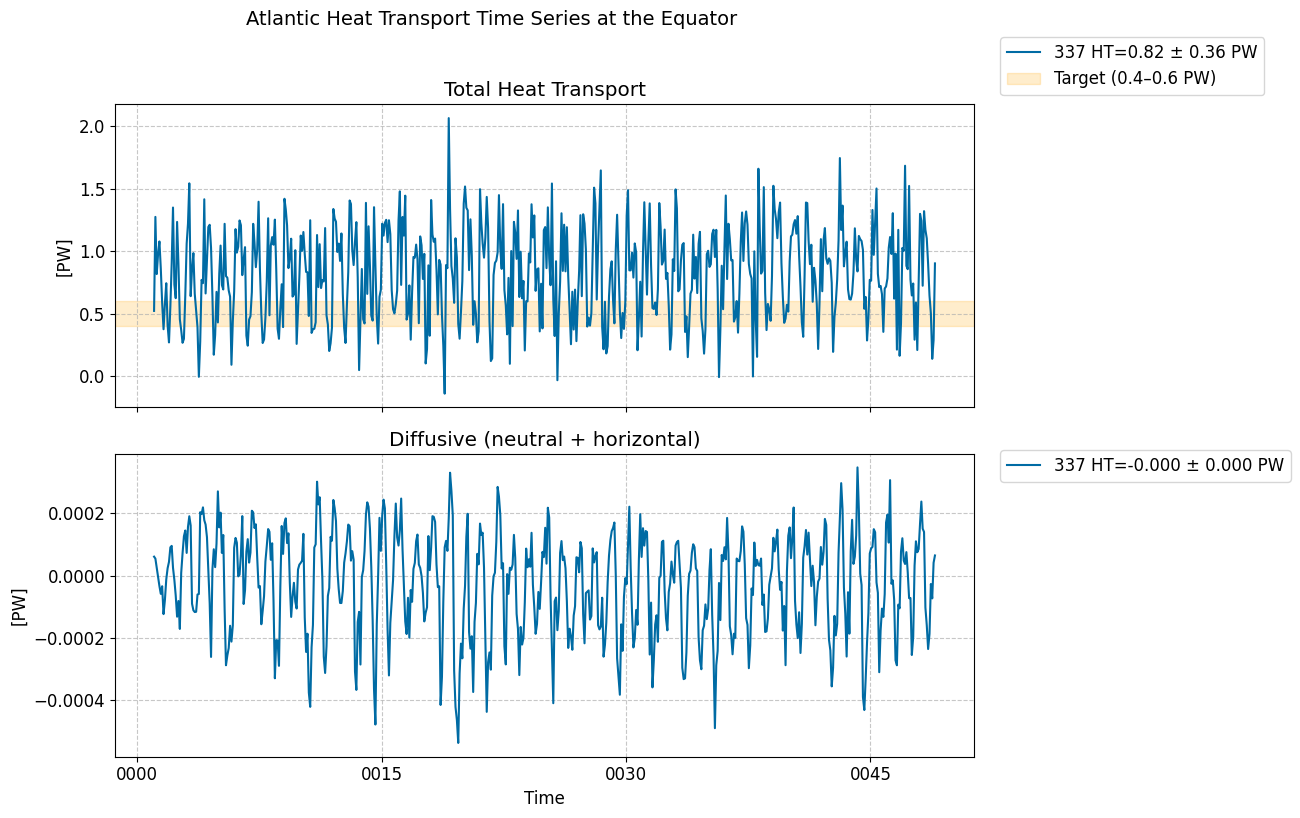

In [10]:
fig, [ax1,ax2] = plt.subplots(nrows=2,figsize=(10,8),sharex=True)

for i in range(len(casename)):
    total = (heat_transport_ts[i].T_ady_2d_atl_eq + heat_transport_ts[i].T_diffy_2d_atl_eq + \
            heat_transport_ts[i].T_hbd_diffy_2d_atl_eq)*1.0e-15 # in PW
    total.plot(ax=ax1, label=str(label[i])+ f" HT={total.mean().values:.2f} ± {total.std().values:.2f} PW") # in PW
    
    diff = (heat_transport_ts[i].T_diffy_2d_atl_eq + heat_transport_ts[i].T_hbd_diffy_2d_atl_eq)*1.0e-15 # in PW
    diff.plot(ax=ax2, label=str(label[i])+ f" HT={diff.mean().values:.3f} ± {diff.std().values:.3f} PW") # in PW

# Add shaded band to highlight target range
ax1.axhspan(0.4, 0.6, color="orange", alpha=0.2, label="Target (0.4–0.6 PW)")

# Collect handles and labels from one axis (assuming they are the same)
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Put one legend on the right
fig.legend(handles1, labels1, loc="center left", bbox_to_anchor=(1, 0.95))
fig.legend(handles2, labels2, loc="center left", bbox_to_anchor=(1, 0.45))

#  Top title
fig.suptitle("Atlantic Heat Transport Time Series at the Equator", fontsize=14, y=1.02) 
# Titles for each subplot
ax1.set_title("Total Heat Transport")
ax2.set_title("Diffusive (neutral + horizontal)")

# Axis labels
ax1.set_xlabel("")
ax2.set_xlabel("Time")               
ax1.set_ylabel("[PW]")
ax2.set_ylabel("[PW]")

# grid
ax1.grid(True, which="both", linestyle="--", alpha=0.7)
ax2.grid(True, which="both", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### Time series @ ~ 26.5 N

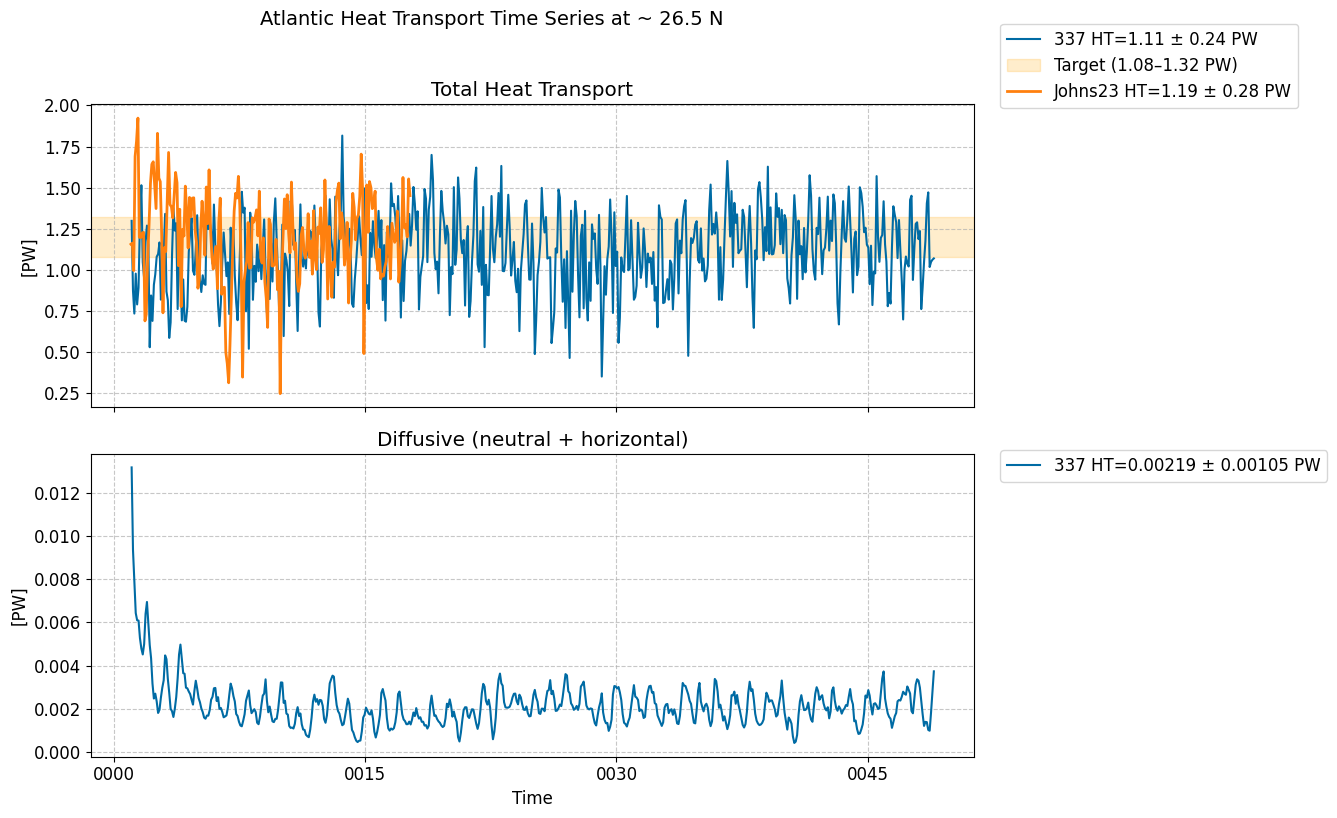

In [11]:
fig, [ax1,ax2] = plt.subplots(nrows=2,figsize=(10,8),sharex=True)

for i in range(len(casename)):
    total = (heat_transport_ts[i].T_ady_2d_rapid + heat_transport_ts[i].T_diffy_2d_rapid + \
            heat_transport_ts[i].T_hbd_diffy_2d_rapid)*1.0e-15 # in PW
    total.plot(ax=ax1, label=str(label[i])+ f" HT={total.mean().values:.2f} ± {total.std().values:.2f} PW") # in PW
    
    diff = (heat_transport_ts[i].T_diffy_2d_rapid + heat_transport_ts[i].T_hbd_diffy_2d_rapid)*1.0e-15 # in PW
    diff.plot(ax=ax2, label=str(label[i])+ f" HT={diff.mean().values:.5f} ± {diff.std().values:.5f} PW") # in PW

# Add shaded band to highlight target range
ax1.axhspan(1.08, 1.32, color="orange", alpha=0.2, label="Target (1.08–1.32 PW)")

# rapid data
obs_shifted = shift_to_year1(pht_johns_2023)*1.0e-15 # PW

ax1.plot(obs_shifted.time ,obs_shifted.values, 
         label='Johns23' f" HT={obs_shifted.mean().values:.2f} ± {obs_shifted.std().values:.2f} PW", lw=2)

# Collect handles and labels from one axis (assuming they are the same)
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Put one legend on the right
fig.legend(handles1, labels1, loc="center left", bbox_to_anchor=(1, 0.95))
fig.legend(handles2, labels2, loc="center left", bbox_to_anchor=(1, 0.45))

#  Top title
fig.suptitle("Atlantic Heat Transport Time Series at ~ 26.5 N", fontsize=14, y=1.02) 
# Titles for each subplot
ax1.set_title("Total Heat Transport")
ax2.set_title("Diffusive (neutral + horizontal)")

# Axis labels
ax1.set_xlabel("")
ax2.set_xlabel("Time")               
ax1.set_ylabel("[PW]")
ax2.set_ylabel("[PW]")

# grid
ax1.grid(True, which="both", linestyle="--", alpha=0.7)
ax2.grid(True, which="both", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### Time series @ ~ 75 N

In [ ]:
fig, [ax1,ax2] = plt.subplots(nrows=2,figsize=(10,8),sharex=True)

for i in range(len(casename)):
    total = (heat_transport_ts[i].T_ady_2d_atl_75N + heat_transport_ts[i].T_diffy_2d_atl_75N + \
            heat_transport_ts[i].T_hbd_diffy_2d_atl_75N)*1.0e-15 # in PW
    total.plot(ax=ax1, label=str(label[i])+ f" HT={total.mean().values:.2f} ± {total.std().values:.2f} PW") # in PW
    
    diff = (heat_transport_ts[i].T_hbd_diffy_2d_atl_75N + heat_transport_ts[i].T_hbd_diffy_2d_atl_75N)*1.0e-15 # in PW
    diff.plot(ax=ax2, label=str(label[i])+ f" HT={diff.mean().values:.5f} ± {diff.std().values:.5f} PW") # in PW

# Collect handles and labels from one axis (assuming they are the same)
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Put one legend on the right
fig.legend(handles1, labels1, loc="center left", bbox_to_anchor=(1, 0.95))
fig.legend(handles2, labels2, loc="center left", bbox_to_anchor=(1, 0.45))

#  Top title
fig.suptitle("Atlantic Heat Transport Time Series at ~ 75 N", fontsize=14, y=1.02) 
# Titles for each subplot
ax1.set_title("Total Heat Transport")
ax2.set_title("Diffusive (neutral + horizontal)")

# Axis labels
ax1.set_xlabel("")
ax2.set_xlabel("Time")               
ax1.set_ylabel("[PW]")
ax2.set_ylabel("[PW]")

# grid
ax1.grid(True, which="both", linestyle="--", alpha=0.7)
ax2.grid(True, which="both", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

## Indo-Pacific Poleward Heat Transport

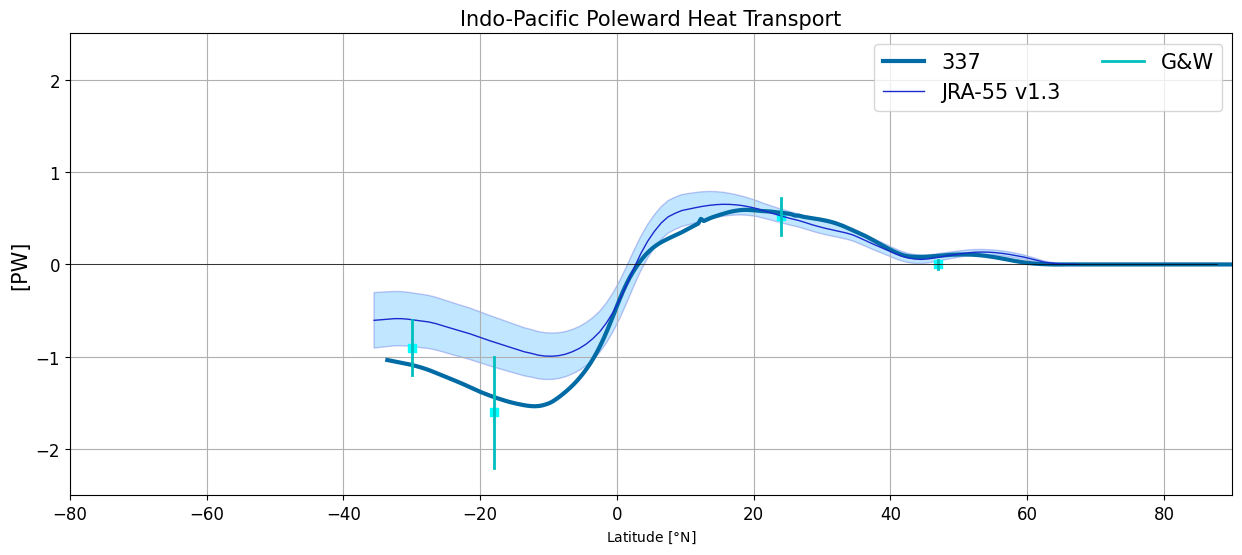

In [12]:
plt.figure(figsize=(15,6))

for i in range(len(casename)):
  basin_code = genBasinMasks(grd[i].geolon, grd[i].geolat, depth[i])
  m = 0*basin_code; m[(basin_code==3) | (basin_code==5)] = 1
  HTplot = heatTrans(heat_transport[i].T_ady_2d, 
           heat_transport[i].T_diffy_2d,
           heat_transport[i].T_hbd_diffy_2d,
           vmask=m*np.roll(m,-1,axis=-2))

  yy = grd[i].geolat_c[:,:].max(axis=-1)
  HTplot[yy<-34] = np.nan
  plt.plot(yy,HTplot, linewidth=3,label=label[i])

jra_mean_indo = jra.nht[:,2,:].mean('time').values
jra_std_indo = jra.nht[:,2,:].std('time').values
plt.plot(jra.lat, jra_mean_indo,'k', label='JRA-55 v1.3', 
                 color='#1B2ACC', lw=1)
plt.fill_between(jra.lat, jra_mean_indo-jra_std_indo, 
                 jra_mean_indo+jra_std_indo,
                 alpha=0.25, edgecolor='#1B2ACC', 
                 facecolor='#089FFF')

#plt.plot(yobs,NCEP['IndoPac'],'k--',linewidth=0.5,label='NCEP')
#plt.plot(yobs,ECMWF['IndoPac'],'k.',linewidth=0.5,label='ECMWF')
plotGandW(GandW['IndoPac']['lat'],GandW['IndoPac']['trans'],GandW['IndoPac']['err'])
plt.xlabel(r'Latitude [$\degree$N]',fontsize=10)
plt.legend(ncol=2,fontsize=15)
plt.title('Indo-Pacific Poleward Heat Transport',fontsize=15)
plt.ylabel('[PW]',fontsize=15)
plt.xlim(-80,90); plt.ylim(-2.5,2.5); plt.grid(True)
plt.plot(y, y*0., 'k', linewidth=0.5);

## By components

In [13]:
colors = ['tab:blue','tab:orange','tab:green','tab:purple','tab:gray','tab:cyan']

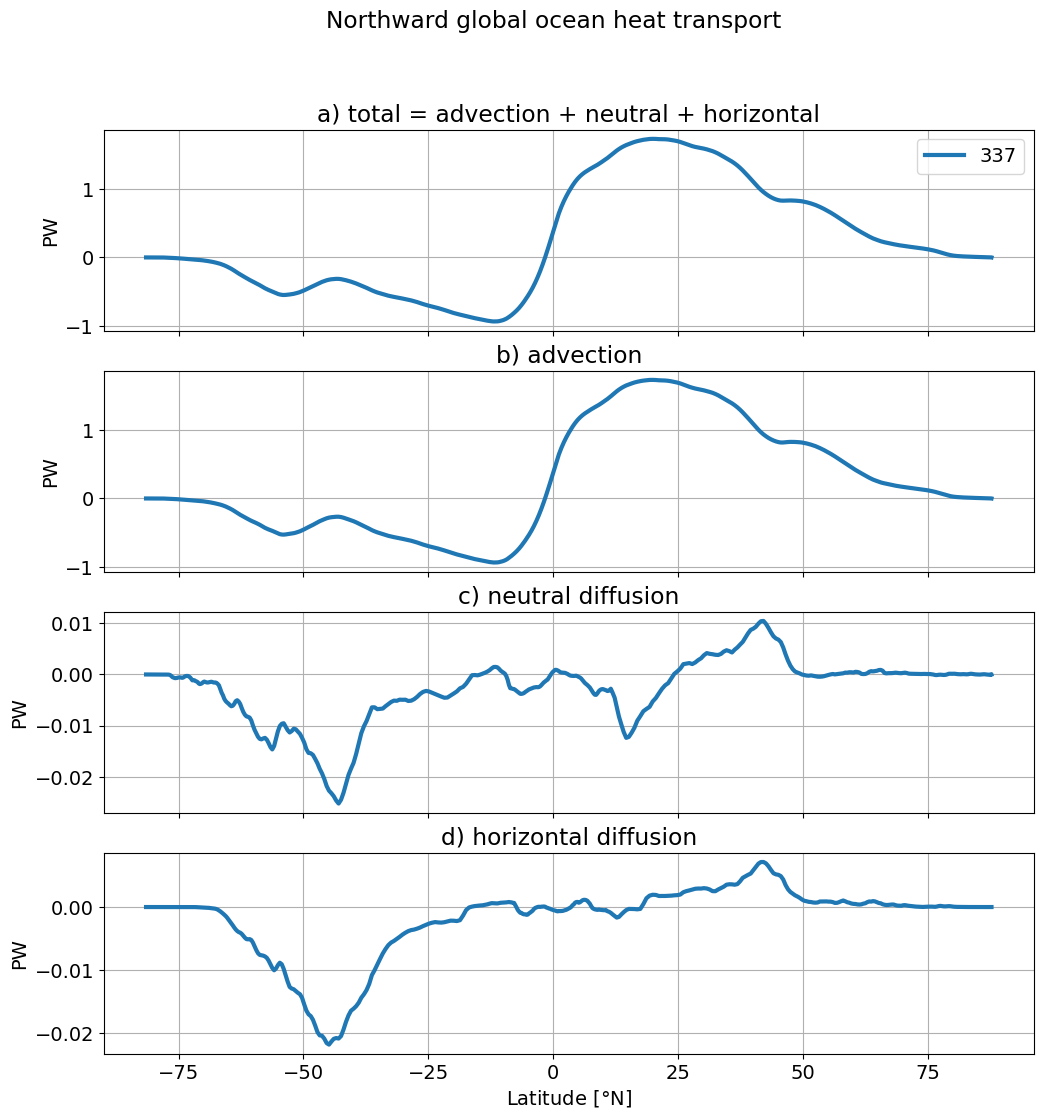

In [14]:
matplotlib.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(12,12), sharex=True)
plt.suptitle('Northward global ocean heat transport')
for i in range(len(casename)):
  #print(i)
  ds = heat_transport[i]
  #print(ds)
  total = (ds.T_ady_2d + ds.T_diffy_2d +
          ds.T_hbd_diffy_2d) 
  (total.sum(dim='xh')* 1.e-15).plot(ax=ax[0], lw=3,label=label[i], color=colors[i]); 
  (ds.T_ady_2d.sum(dim='xh')* 1.e-15).plot(ax=ax[1], lw=3,label=label[i], color=colors[i]); 
  (ds.T_diffy_2d.sum(dim='xh') * 1.e-15).plot(ax=ax[2], lw=3, color=colors[i]); 
  (ds.T_hbd_diffy_2d.sum(dim='xh') * 1.e-15).plot(ax=ax[3], lw=3, color=colors[i]); 

ax[0].legend(ncol=2)
ax[0].grid(); ax[1].grid();ax[2].grid(); ax[3].grid()
#ax[0].set_ylim(-1.5, 1.5); ax[1].set_ylim(-1.5, 1.5)
#ax[2].set_ylim(-0.075, 0.05); ax[3].set_ylim(-0.075, 0.05)
ax[0].set_ylabel('PW');ax[1].set_ylabel('PW');ax[2].set_ylabel('PW'); ax[3].set_ylabel('PW')
ax[0].set_xlabel('');ax[1].set_xlabel(''); ax[2].set_xlabel(''); ax[3].set_xlabel('Latitude [$\degree$N]')

ax[0].set_title('a) total = advection + neutral + horizontal')
ax[1].set_title('b) advection')
ax[2].set_title('c) neutral diffusion');
ax[3].set_title('d) horizontal diffusion');